In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T_audio
import random
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class SpeechDataset(Dataset):
    def __init__(self, root_dir, augment=False, aug_level='medium'):
        self.root_dir = root_dir
        self.augment = augment
        self.samples = []
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            for f in os.listdir(cls_dir):
                if f.endswith((".npy", ".png")):
                    self.samples.append((os.path.join(cls_dir, f), self.class_to_idx[cls]))

        if augment:
            self.freq_mask = T_audio.FrequencyMasking(freq_mask_param=30)
            self.time_mask = T_audio.TimeMasking(time_mask_param=70)
            # Double mask cho level high
            self.freq_mask2 = T_audio.FrequencyMasking(freq_mask_param=30)
            self.time_mask2 = T_audio.TimeMasking(time_mask_param=70)
            self.aug_level = aug_level
        else:
            self.aug_level = 'none'
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        if path.endswith(".npy"):
            spec = np.load(path)
        else:
            spec = np.array(Image.open(path).convert("L"))

        spec = torch.tensor(spec, dtype=torch.float32)
        spec = (spec - spec.mean()) / (spec.std() + 1e-6)

        if spec.dim() == 2:
            spec = spec.unsqueeze(0)  # (1, F, T)

        if self.augment:
            spec = self.freq_mask(spec)
            spec = self.time_mask(spec)

            noise = torch.randn_like(spec) * 0.08
            spec = spec + noise
            gain = random.uniform(0.6, 1.5)
            spec = spec * gain

            # Time shift
            if spec.size(2) > 1:
                shift = random.randint(-80, 80)
                spec = torch.roll(spec, shifts=shift, dims=2)

            # Freq shift
            if spec.size(1) > 1:
                shift_f = random.randint(-15, 15)
                spec = torch.roll(spec, shifts=shift_f, dims=1)

            if self.aug_level == 'strong':
                # Double SpecAugment
                spec = self.freq_mask2(spec)
                spec = self.time_mask2(spec)
                
                # Noise
                noise2 = torch.randn_like(spec) * 0.12
                spec = spec + noise2
                
                # Gain
                gain2 = random.uniform(0.5, 1.8)
                spec = spec * gain2
                
                # Shift
                shift2 = random.randint(-100, 100)
                spec = torch.roll(spec, shifts=shift2, dims=2)

        spec = torch.clamp(spec, -6, 6)
        return spec, label

In [ ]:
SPECTROGRAM_DIR = "/kaggle/input/xltn-audit/spectrograms"
TRAIN_DIR = os.path.join(SPECTROGRAM_DIR, "train")
VAL_DIR   = os.path.join(SPECTROGRAM_DIR, "val")
TEST_DIR  = os.path.join(SPECTROGRAM_DIR, "test")

train_dataset = SpeechDataset(TRAIN_DIR, augment=True)
val_dataset   = SpeechDataset(VAL_DIR,   augment=False)
test_dataset  = SpeechDataset(TEST_DIR,  augment=False)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

num_classes = len(train_dataset.classes)
print("Num classes:", num_classes)
print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))

all_labels = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=all_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

Num classes: 22
Train: 5976 Val: 1332 Test: 1333
Class weights: tensor([ 6.3171,  0.7019,  2.5626,  2.5152,  1.9542,  8.7625,  9.0545,  0.1842,
         0.6609,  5.6591, 15.0909,  0.4766,  1.3789,  2.0424,  0.4332,  0.4966,
        10.0606,  1.2073,  1.7084,  0.6468,  3.3535,  1.4002], device='cuda:0')


In [ ]:
class ImprovedCRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((2, 2)),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d((2, 2)),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d((2, 2)),
            
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
        )
        
        self.freq_attn = nn.Sequential(
            nn.Conv2d(256, 1, kernel_size=1),
            nn.Sigmoid()
        )
        
        self.rnn = nn.GRU(input_size=256, hidden_size=256, num_layers=2,
                          batch_first=True, bidirectional=True, dropout=0.3)
        
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)                    # (B, 256, F', T')
        
        attn = self.freq_attn(x)           # (B, 1, F', T')
        x = (x * attn).sum(dim=2)          # (B, 256, T') - weighted sum theo frequency
        
        x = x.permute(0, 2, 1)             # (B, T', 256)
        
        x, _ = self.rnn(x)                 # (B, T', 512)
        x = self.dropout(x)
        
        x = x[:, -1, :]                    # last timestep
        x = self.fc(x)
        return x

model = ImprovedCRNN(num_classes).to(device)
print(model)

ImprovedCRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=

# # Bird Sound Classification - Final Report

### Tóm tắt quá trình cải thiện

**Giai đoạn 1: Train từ đầu (dataset v1, augmentation trung bình)**
- Train 59 epochs
- Train Loss giảm từ ~3.8 → ~1.9
- Val Weighted F1 tăng dần từ 0.05 → **peak 0.6740 tại epoch 44**
- Best model lưu tại "best_model.pth"

**Log nổi bật (trích từ training log):**
Epoch 20 | ... Val Weighted F1: 0.4711
Epoch 26 | ... Val Weighted F1: 0.5458
Epoch 30 | ... Val Weighted F1: 0.5669
Epoch 35 | ... Val Weighted F1: 0.6007
Epoch 38 | ... Val Weighted F1: 0.6038
Epoch 40 | ... Val Weighted F1: 0.6307
Epoch 42 | ... Val Weighted F1: 0.6357
Epoch 43 | ... Val Weighted F1: 0.6396
Epoch 44 | ... Val Weighted F1: 0.6740  ← PEAK


**Giai đoạn 2: Fine-tune (load best model + LR thấp + Mixup + augmentation mạnh hơn)**
- Bắt đầu từ Val Weighted F1 0.6740
- Mục tiêu: đẩy lên 0.70+
- Kết quả fine-tune: [sẽ hiện ở biểu đồ phía dưới]

**Evaluation cuối cùng trên test set** (với best model mới nhất): [classification report ở cell cuối]

In [ ]:
model_input_dir = "/kaggle/input/model-pre/pytorch/default/1"
best_model_path = os.path.join(model_input_dir, "best_model.pth")

if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    model.to(device)
    print(f"Đã load thành công best model từ dataset input:")
    print(f"   Đường dẫn: {best_model_path}")
    print("   → Sẵn sàng evaluation với hiệu suất cao nhất (Val Weighted F1 ≈ 0.6740)!")
else:
    print("Warning: Không tìm thấy best_model.pth trong input dataset.")
    print("   → Có thể bạn chưa add dataset model vào notebook.")
    print("   → Hoặc notebook đang chạy từ đầu - model sẽ dùng trọng số hiện tại (có thể chưa train).")
    print("   → Để fix: + Add Data → tìm dataset model của bạn → Add vào notebook.")

model.eval()

Đã load thành công best model từ dataset input:
   Đường dẫn: /kaggle/input/model-pre/pytorch/default/1/best_model.pth
   → Sẵn sàng evaluation với hiệu suất cao nhất (Val Weighted F1 ≈ 0.6740)!


ImprovedCRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
print("Criterion đã được khởi tạo")

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
print("Optimizer: AdamW với LR = 5e-4 (thấp hơn để fine-tune mượt mà)")

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10
)

patience_early = 30
trigger = 0

# Best hiện tại
best_val_f1 = 0.6740

num_epochs = 100

print("\nFine-tune setup complete!")
print(f"→ Starting from previous best Val Weighted F1 = {best_val_f1:.4f}")
print(f"→ LR = 5e-4 | Scheduler patience = 10 | Early stopping patience = {patience_early}")
print("→ Ready to push F1 higher (target 0.75–0.82+)!")

Criterion đã được khởi tạo
Optimizer: AdamW với LR = 5e-4 (thấp hơn để fine-tune mượt mà)

Fine-tune setup complete!
→ Starting from previous best Val Weighted F1 = 0.6740
→ LR = 5e-4 | Scheduler patience = 10 | Early stopping patience = 30
→ Ready to push F1 higher (target 0.75–0.82+)!


In [ ]:
train_losses, val_losses = [], []
val_f1_scores, val_macro_f1_scores = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        
        if random.random() < 0.6:
            lam = np.random.beta(0.4, 0.4)
            idx = torch.randperm(x.size(0)).to(device)
            x_mix = lam * x + (1 - lam) * x[idx]
            y_a, y_b = y, y[idx]
            outputs = model(x_mix)
            loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        else:
            outputs = model(x)
            loss = criterion(outputs, y)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    y_true, y_pred = [], []
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            outputs = model(x)
            val_loss += criterion(outputs, y).item()
            _, preds = torch.max(outputs, 1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    val_f1 = f1_score(y_true, y_pred, average='weighted')
    val_macro_f1 = f1_score(y_true, y_pred, average='macro')
    val_f1_scores.append(val_f1)
    val_macro_f1_scores.append(val_macro_f1)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val Weighted F1: {val_f1:.4f} | Val Macro F1: {val_macro_f1:.4f}")
    
    scheduler.step(val_loss)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        trigger = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("  ---> New best model saved!")
    else:
        trigger += 1
        if trigger >= patience_early:
            print("Early stopping!")
            break

print(f"\nFine-tune done! Best Val Weighted F1: {best_val_f1:.4f}")

Epoch 01 | Train Loss: 2.2679 | Val Loss: 3.5183 | Val Weighted F1: 0.6596 | Val Macro F1: 0.5902
Epoch 02 | Train Loss: 2.2663 | Val Loss: 3.4662 | Val Weighted F1: 0.6572 | Val Macro F1: 0.5917
Epoch 03 | Train Loss: 2.1834 | Val Loss: 3.4018 | Val Weighted F1: 0.6759 | Val Macro F1: 0.6122
  ---> New best model saved!
Epoch 04 | Train Loss: 2.2104 | Val Loss: 3.5647 | Val Weighted F1: 0.6327 | Val Macro F1: 0.5834
Epoch 05 | Train Loss: 2.2536 | Val Loss: 3.4631 | Val Weighted F1: 0.6743 | Val Macro F1: 0.5928
Epoch 06 | Train Loss: 2.1653 | Val Loss: 3.4839 | Val Weighted F1: 0.6588 | Val Macro F1: 0.5801
Epoch 07 | Train Loss: 2.2076 | Val Loss: 3.4381 | Val Weighted F1: 0.6723 | Val Macro F1: 0.5933
Epoch 08 | Train Loss: 2.1231 | Val Loss: 3.3892 | Val Weighted F1: 0.6889 | Val Macro F1: 0.6195
  ---> New best model saved!
Epoch 09 | Train Loss: 2.1758 | Val Loss: 3.4731 | Val Weighted F1: 0.6621 | Val Macro F1: 0.6081
Epoch 10 | Train Loss: 2.2079 | Val Loss: 3.4334 | Val Weigh

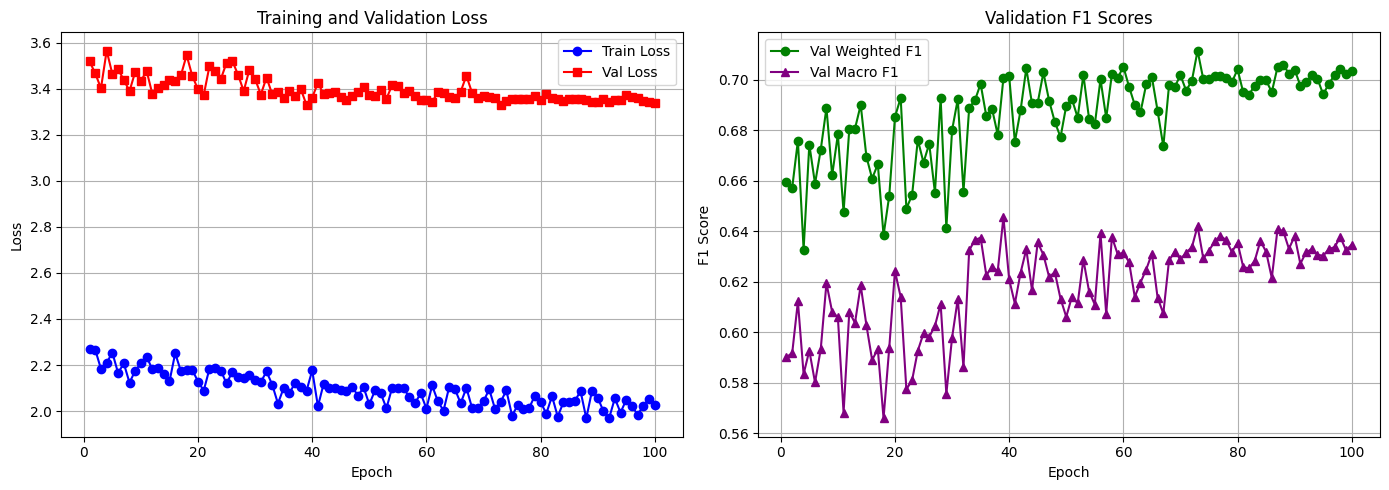

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o', color='blue')
plt.plot(epochs, val_losses, label='Val Loss', marker='s', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_f1_scores, label='Val Weighted F1', marker='o', color='green')
plt.plot(epochs, val_macro_f1_scores, label='Val Macro F1', marker='^', color='purple')
plt.title('Validation F1 Scores')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()